In [1]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [68]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_MET400_multiplane_dphi_test2/tables')
# PLANEs = ['CP0', 'CP1', 'CP2', 'CP3', 'SP0', 'SP1', 'SP2', 'SP3']
PLANEs = ['CP0', 'CP1', 'CP2', 'CP3']
tables = {}

for PLANE in PLANEs:
    SAMPLE = f'C1N2ML_M500_485_ct20_2018_{PLANE}_evt_leading_vtx_{PLANE}_dphiMET_vs_{PLANE}_Max_ML_score_withdata'
    loCut_key = '0.00,0.00'

    TABLE = 'gridsearch_disco.pkl'
    TABLE_PATH = HISTDIR / SAMPLE / TABLE

    with open(TABLE_PATH, 'rb') as f:
        table = pickle.load(f)
    
    tables[PLANE] = table


print('Keys in the loaded table:')
for key in table.keys():
    print(key)


Keys in the loaded table:
0.00,0.00


In [4]:
for PLANE in PLANEs:
    Z_As = tables[PLANE][loCut_key]['Z_A']

In [5]:
# SP0_tf = tables['SP0'][loCut_key][B_key] * tables['SP0'][loCut_key][C_key] / tables['SP0'][loCut_key][D_key]
# SP1_tf = tables['SP1'][loCut_key][B_key] * tables['SP1'][loCut_key][C_key] / tables['SP1'][loCut_key][D_key]
# SP2_tf = tables['SP2'][loCut_key][B_key] * tables['SP2'][loCut_key][C_key] / tables['SP2'][loCut_key][D_key]
# SP3_tf = tables['SP3'][loCut_key][B_key] * tables['SP3'][loCut_key][C_key] / tables['SP3'][loCut_key][D_key]

# CP0_tf = tables['CP0'][loCut_key][B_key] * tables['CP0'][loCut_key][C_key] / tables['CP0'][loCut_key][D_key]
# CP1_tf = tables['CP1'][loCut_key][B_key] * tables['CP1'][loCut_key][C_key] / tables['CP1'][loCut_key][D_key]
# CP2_tf = tables['CP2'][loCut_key][B_key] * tables['CP2'][loCut_key][C_key] / tables['CP2'][loCut_key][D_key]
# CP3_tf = tables['CP3'][loCut_key][B_key] * tables['CP3'][loCut_key][C_key] / tables['CP3'][loCut_key][D_key]


# xcut = 1.5
# ycut  = 0.9992

# print('SP0_tf:', SP0_tf.loc[xcut, ycut])
# print('SP1_tf:', SP1_tf.loc[xcut, ycut])
# print('SP2_tf:', SP2_tf.loc[xcut, ycut])
# print('SP3_tf:', SP3_tf.loc[xcut, ycut])

# print('CP0_tf:', CP0_tf.loc[xcut, ycut])
# print('CP1_tf:', CP1_tf.loc[xcut, ycut])
# print('CP2_tf:', CP2_tf.loc[xcut, ycut])
# print('CP3_tf:', CP3_tf.loc[xcut, ycut])

In [11]:
xcut = 1.5
ycut  = 0.90


A_key = 'bkg_NA'
B_key = 'bkg_NB'
C_key = 'bkg_NC'
D_key = 'bkg_ND'


A_unc_key = 'bkg_NA_unc'
B_unc_key = 'bkg_NB_unc'
C_unc_key = 'bkg_NC_unc'
D_unc_key = 'bkg_ND_unc'


SP0_A_n = tables['SP0'][loCut_key][A_key].loc[xcut, ycut]
SP0_B_n = tables['SP0'][loCut_key][B_key].loc[xcut, ycut]
SP0_C_n = tables['SP0'][loCut_key][C_key].loc[xcut, ycut]
SP0_D_n = tables['SP0'][loCut_key][D_key].loc[xcut, ycut]
SP1_A_n = tables['SP1'][loCut_key][A_key].loc[xcut, ycut]
SP1_B_n = tables['SP1'][loCut_key][B_key].loc[xcut, ycut]
SP1_C_n = tables['SP1'][loCut_key][C_key].loc[xcut, ycut]
SP1_D_n = tables['SP1'][loCut_key][D_key].loc[xcut, ycut]
SP2_A_n = tables['SP2'][loCut_key][A_key].loc[xcut, ycut]
SP2_B_n = tables['SP2'][loCut_key][B_key].loc[xcut, ycut]
SP2_C_n = tables['SP2'][loCut_key][C_key].loc[xcut, ycut]
SP2_D_n = tables['SP2'][loCut_key][D_key].loc[xcut, ycut]
SP3_A_n = tables['SP3'][loCut_key][A_key].loc[xcut, ycut]
SP3_B_n = tables['SP3'][loCut_key][B_key].loc[xcut, ycut]
SP3_C_n = tables['SP3'][loCut_key][C_key].loc[xcut, ycut]
SP3_D_n = tables['SP3'][loCut_key][D_key].loc[xcut, ycut]

SP0_A_s = tables['SP0'][loCut_key][A_unc_key].loc[xcut, ycut]
SP0_B_s = tables['SP0'][loCut_key][B_unc_key].loc[xcut, ycut]
SP0_C_s = tables['SP0'][loCut_key][C_unc_key].loc[xcut, ycut]
SP0_D_s = tables['SP0'][loCut_key][D_unc_key].loc[xcut, ycut]
SP1_A_s = tables['SP1'][loCut_key][A_unc_key].loc[xcut, ycut]
SP1_B_s = tables['SP1'][loCut_key][B_unc_key].loc[xcut, ycut]
SP1_C_s = tables['SP1'][loCut_key][C_unc_key].loc[xcut, ycut]
SP1_D_s = tables['SP1'][loCut_key][D_unc_key].loc[xcut, ycut]
SP2_A_s = tables['SP2'][loCut_key][A_unc_key].loc[xcut, ycut]
SP2_B_s = tables['SP2'][loCut_key][B_unc_key].loc[xcut, ycut]
SP2_C_s = tables['SP2'][loCut_key][C_unc_key].loc[xcut, ycut]
SP2_D_s = tables['SP2'][loCut_key][D_unc_key].loc[xcut, ycut]
SP3_A_s = tables['SP3'][loCut_key][A_unc_key].loc[xcut, ycut]
SP3_B_s = tables['SP3'][loCut_key][B_unc_key].loc[xcut, ycut]
SP3_C_s = tables['SP3'][loCut_key][C_unc_key].loc[xcut, ycut]
SP3_D_s = tables['SP3'][loCut_key][D_unc_key].loc[xcut, ycut]


SP0_A = ufloat(SP0_A_n, SP0_A_s)
SP0_B = ufloat(SP0_B_n, SP0_B_s)
SP0_C = ufloat(SP0_C_n, SP0_C_s)
SP0_D = ufloat(SP0_D_n, SP0_D_s)
SP1_A = ufloat(SP1_A_n, SP1_A_s)
SP1_B = ufloat(SP1_B_n, SP1_B_s)
SP1_C = ufloat(SP1_C_n, SP1_C_s)
SP1_D = ufloat(SP1_D_n, SP1_D_s)
SP2_A = ufloat(SP2_A_n, SP2_A_s)
SP2_B = ufloat(SP2_B_n, SP2_B_s)
SP2_C = ufloat(SP2_C_n, SP2_C_s)
SP2_D = ufloat(SP2_D_n, SP2_D_s)
SP3_A = ufloat(SP3_A_n, SP3_A_s)
SP3_B = ufloat(SP3_B_n, SP3_B_s)
SP3_C = ufloat(SP3_C_n, SP3_C_s)
SP3_D = ufloat(SP3_D_n, SP3_D_s)

SP0_tf = SP0_C / SP0_D if SP0_D.n != 0 else ufloat(0,0)
SP1_tf = SP1_C / SP1_D if SP1_D.n != 0 else ufloat(0,0)
SP2_tf = SP2_C / SP2_D if SP2_D.n != 0 else ufloat(0,0)
SP3_tf = SP3_C / SP3_D if SP3_D.n != 0 else ufloat(0,0)

SP0_tfAB = SP0_A / SP0_B if SP0_B.n != 0 else ufloat(0,0)
SP1_tfAB = SP1_A / SP1_B if SP1_B.n != 0 else ufloat(0,0)
SP2_tfAB = SP2_A / SP2_B if SP2_B.n != 0 else ufloat(0,0)
SP3_tfAB = SP3_A / SP3_B if SP3_B.n != 0 else ufloat(0,0)

print('SP0_tf:', SP0_tf)
print('SP1_tf:', SP1_tf)
print('SP2_tf:', SP2_tf)
print('SP3_tf:', SP3_tf)

print('SP0_tfAB:', SP0_tfAB)
print('SP1_tfAB:', SP1_tfAB)
print('SP2_tfAB:', SP2_tfAB)
print('SP3_tfAB:', SP3_tfAB)

KeyError: 'SP0'

In [12]:
xcut = 1.5
ycut  = 0.70

CP0_A_n = tables['CP0'][loCut_key][A_key].loc[xcut, ycut]
CP0_B_n = tables['CP0'][loCut_key][B_key].loc[xcut, ycut]
CP0_C_n = tables['CP0'][loCut_key][C_key].loc[xcut, ycut]
CP0_D_n = tables['CP0'][loCut_key][D_key].loc[xcut, ycut]
CP1_A_n = tables['CP1'][loCut_key][A_key].loc[xcut, ycut]
CP1_B_n = tables['CP1'][loCut_key][B_key].loc[xcut, ycut]
CP1_C_n = tables['CP1'][loCut_key][C_key].loc[xcut, ycut]
CP1_D_n = tables['CP1'][loCut_key][D_key].loc[xcut, ycut]
CP2_A_n = tables['CP2'][loCut_key][A_key].loc[xcut, ycut]
CP2_B_n = tables['CP2'][loCut_key][B_key].loc[xcut, ycut]
CP2_C_n = tables['CP2'][loCut_key][C_key].loc[xcut, ycut]
CP2_D_n = tables['CP2'][loCut_key][D_key].loc[xcut, ycut]
CP3_A_n = tables['CP2'][loCut_key][A_key].loc[xcut, ycut]
CP3_B_n = tables['CP3'][loCut_key][B_key].loc[xcut, ycut]
CP3_C_n = tables['CP3'][loCut_key][C_key].loc[xcut, ycut]
CP3_D_n = tables['CP3'][loCut_key][D_key].loc[xcut, ycut]


CP0_A_s = tables['CP0'][loCut_key][A_unc_key].loc[xcut, ycut]
CP0_B_s = tables['CP0'][loCut_key][B_unc_key].loc[xcut, ycut]
CP0_C_s = tables['CP0'][loCut_key][C_unc_key].loc[xcut, ycut]
CP0_D_s = tables['CP0'][loCut_key][D_unc_key].loc[xcut, ycut]
CP1_A_s = tables['CP1'][loCut_key][A_unc_key].loc[xcut, ycut]
CP1_B_s = tables['CP1'][loCut_key][B_unc_key].loc[xcut, ycut]
CP1_C_s = tables['CP1'][loCut_key][C_unc_key].loc[xcut, ycut]
CP1_D_s = tables['CP1'][loCut_key][D_unc_key].loc[xcut, ycut]
CP2_A_s = tables['CP1'][loCut_key][A_unc_key].loc[xcut, ycut]
CP2_B_s = tables['CP2'][loCut_key][B_unc_key].loc[xcut, ycut]
CP2_C_s = tables['CP2'][loCut_key][C_unc_key].loc[xcut, ycut]
CP2_D_s = tables['CP2'][loCut_key][D_unc_key].loc[xcut, ycut]
CP3_A_s = tables['CP3'][loCut_key][A_unc_key].loc[xcut, ycut]
CP3_B_s = tables['CP3'][loCut_key][B_unc_key].loc[xcut, ycut]
CP3_C_s = tables['CP3'][loCut_key][C_unc_key].loc[xcut, ycut]
CP3_D_s = tables['CP3'][loCut_key][D_unc_key].loc[xcut, ycut]

CP0_A = ufloat(CP0_A_n, CP0_A_s)
CP0_B = ufloat(CP0_B_n, CP0_B_s)
CP0_C = ufloat(CP0_C_n, CP0_C_s)
CP0_D = ufloat(CP0_D_n, CP0_D_s)
CP1_A = ufloat(CP1_A_n, CP1_A_s)
CP1_B = ufloat(CP1_B_n, CP1_B_s)
CP1_C = ufloat(CP1_C_n, CP1_C_s)
CP1_D = ufloat(CP1_D_n, CP1_D_s)
CP2_A = ufloat(CP2_A_n, CP2_A_s)
CP2_B = ufloat(CP2_B_n, CP2_B_s)
CP2_C = ufloat(CP2_C_n, CP2_C_s)
CP2_D = ufloat(CP2_D_n, CP2_D_s)
CP3_A = ufloat(CP3_A_n, CP3_A_s)
CP3_B = ufloat(CP3_B_n, CP3_B_s)
CP3_C = ufloat(CP3_C_n, CP3_C_s)
CP3_D = ufloat(CP3_D_n, CP3_D_s)



CP0_tf = CP0_C / CP0_D if CP0_D.n != 0 else ufloat(0,0)
CP1_tf = CP1_C / CP1_D if CP1_D.n != 0 else ufloat(0,0)
CP2_tf = CP2_C / CP2_D if CP2_D.n != 0 else ufloat(0,0)
CP3_tf = CP3_C / CP3_D if CP3_D.n != 0 else ufloat(0,0)



CP0_tfAB = CP0_A / CP0_B if CP0_B.n != 0 else ufloat(0,0)
CP1_tfAB = CP1_A / CP1_B if CP1_B.n != 0 else ufloat(0,0)
CP2_tfAB = CP2_A / CP2_B if CP2_B.n != 0 else ufloat(0,0)
CP3_tfAB = CP3_A / CP3_B if CP3_B.n != 0 else ufloat(0,0)





print('CP0_tf:', CP0_tf)
print('CP1_tf:', CP1_tf)
print('CP2_tf:', CP2_tf)
print('CP3_tf:', CP3_tf)
print()


print('CP0_tfAB:', CP0_tfAB)
print('CP1_tfAB:', CP1_tfAB)
print('CP2_tfAB:', CP2_tfAB)
print('CP3_tfAB:', CP3_tfAB)


CP0_tf: 0.339+/-0.005
CP1_tf: 0.309+/-0.004
CP2_tf: 0.306+/-0.006
CP3_tf: 0.223+/-0.026

CP0_tfAB: 0.298+/-0.015
CP1_tfAB: 0.291+/-0.014
CP2_tfAB: 0.311+/-0.024
CP3_tfAB: 2.73+/-0.28


In [66]:
print('SP0_tf / CP0_tf: ', SP0_tf / CP0_tf)
print('SP1_tf / CP1_tf: ', SP1_tf / CP1_tf)
print('SP2_tf / CP2_tf: ', SP2_tf / CP2_tf)
print('SP3_tf / CP3_tf: ', SP3_tf / CP3_tf)

SP0_tf / CP0_tf:  1.063+/-0.010
SP1_tf / CP1_tf:  1.047+/-0.016
SP2_tf / CP2_tf:  1.017+/-0.026
SP3_tf / CP3_tf:  0.95+/-0.14


In [67]:
print('SP1_tf / SP0_tf: ', SP1_tf / SP0_tf)
print('SP2_tf / SP1_tf: ', SP2_tf / SP1_tf)
print('SP3_tf / SP2_tf: ', SP3_tf / SP2_tf)

SP1_tf / SP0_tf:  0.936+/-0.013
SP2_tf / SP1_tf:  0.915+/-0.022
SP3_tf / SP2_tf:  0.80+/-0.11


In [7]:
print('CP1_tf / CP0_tf: ', CP1_tf / CP0_tf)
print('CP2_tf / CP1_tf: ', CP2_tf / CP1_tf)
print('CP3_tf / CP2_tf: ', CP3_tf / CP2_tf)

NameError: name 'CP1_tf' is not defined

In [69]:
for PLANE in PLANEs:
    print(f"{PLANE} significance in A: ", tables[PLANE][loCut_key]['Z_A'].loc[xcut, ycut])

CP0 significance in A:  0.02965770535129229
CP1 significance in A:  0.0205292139083359
CP2 significance in A:  0.12824166760028047
CP3 significance in A:  0.2931776282994489
SP0 significance in A:  0.02946744504602838
SP1 significance in A:  0.08948580899822788
SP2 significance in A:  0.17115059366331858
SP3 significance in A:  0.25095086495468644


In [70]:
for PLANE in PLANEs:
    print(f"{PLANE} significance in B: ", tables[PLANE][loCut_key]['Z_B'].loc[xcut, ycut])

CP0 significance in B:  0.16714646921397017
CP1 significance in B:  0.21742471585020326
CP2 significance in B:  0.3804572217198223
CP3 significance in B:  0.8092064487806088
SP0 significance in B:  0.14485670587318436
SP1 significance in B:  0.5504909815292239
SP2 significance in B:  1.143021114947433
SP3 significance in B:  1.4852385091605336


In [71]:
for PLANE in PLANEs:
    print(f"{PLANE} SNR in B: ", tables[PLANE][loCut_key]['sig_NB'].loc[xcut, ycut] / tables[PLANE][loCut_key][B_key].loc[xcut, ycut])

CP0 SNR in B:  0.07911935790068984
CP1 SNR in B:  0.09267886107646191
CP2 SNR in B:  0.1397447072791384
CP3 SNR in B:  0.3828962998928517
SP0 SNR in B:  0.6861172878217068
SP1 SNR in B:  0.8992345218736675
SP2 SNR in B:  4.350810196192776
SP3 SNR in B:  -229.4511462590454


In [ ]:
dPhi = 1.5
ML = 0.9996


print(tables['SP2'][key]['sig_NB'].loc[dPhi,ML])
print(tables['SP2'][key]['bkg_NB'].loc[dPhi,ML])
print(tables['SP2'][key]['bkg_NA'].loc[dPhi,ML] *     \
      tables['SP2'][key]['bkg_ND'].loc[dPhi,ML] /     \
      tables['SP2'][key]['bkg_NC'].loc[dPhi,ML]) 

1.2035578503334134
0.13770250432043632
0.3649046866130526


In [130]:
tables['SP3'][key]['sig_NA'].loc[dPhi,ML]

0.213083802125562

In [131]:
tables['SP3'][key]['bkg_NA'].loc[dPhi,ML]

0.0678622089513205

In [117]:
tables['SP2'][key]['bkg_NC'].loc[dPhi,ML]

1114.1723990687328

In [118]:
tables['SP2'][key]['bkg_ND'].loc[dPhi,ML]

3526.9018196774573

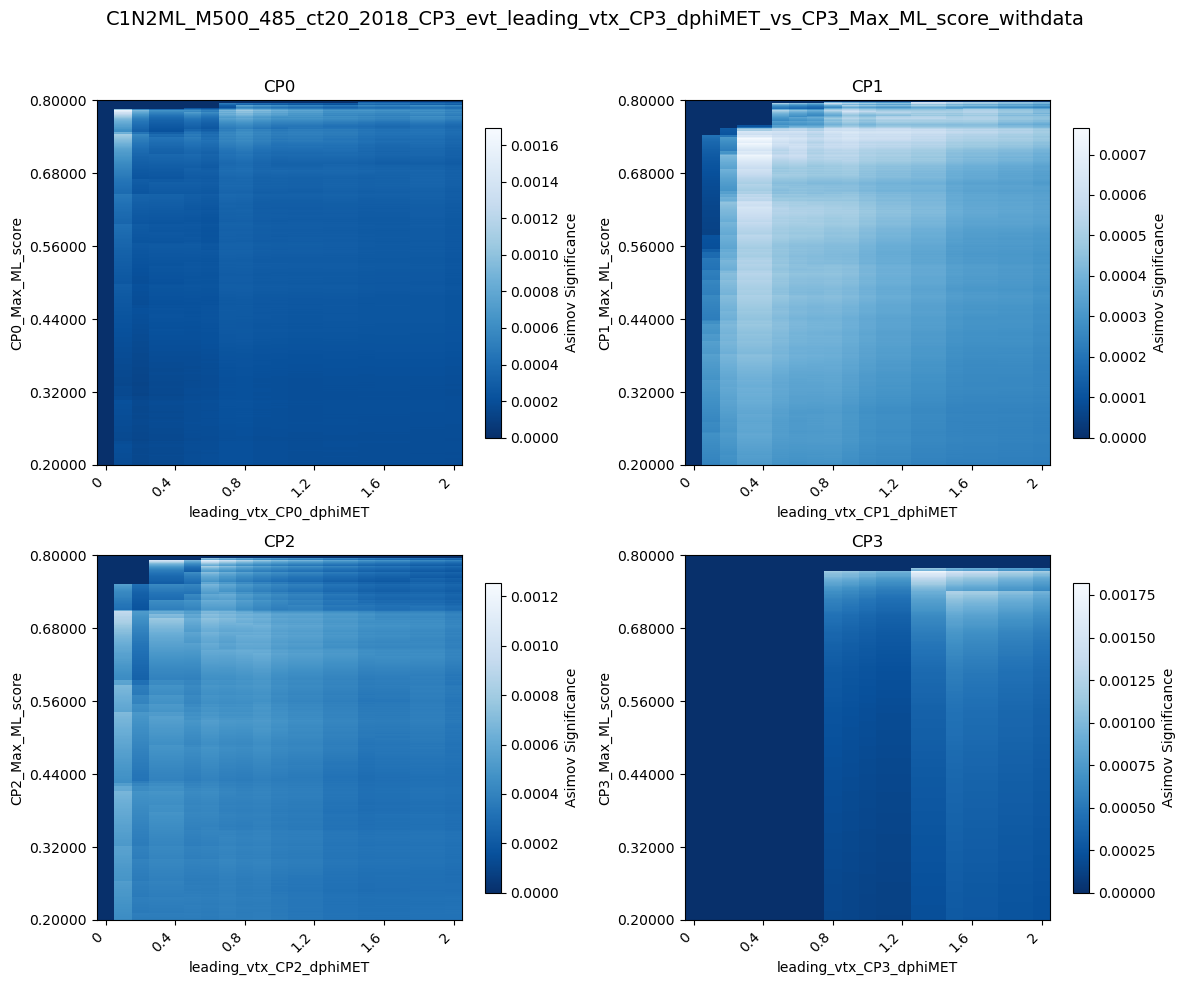

In [69]:
import matplotlib.ticker as mtick
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

plotlim_xlo = 0
plotlim_xup = 2
plotlim_ylo = 0.2
plotlim_yup = 0.8

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, PLANE in zip(axes, PLANEs[:4]):

    X_b = tables[PLANE][key]['Z_B']
    X_b = X_b.loc[plotlim_xlo:plotlim_xup, plotlim_ylo:plotlim_yup]
    X_b = X_b.fillna(0)

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=absmax,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel(f'leading_vtx_{PLANE}_dphiMET')
    ax.set_ylabel(f'{PLANE}_Max_ML_score')
    ax.set_title(PLANE)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


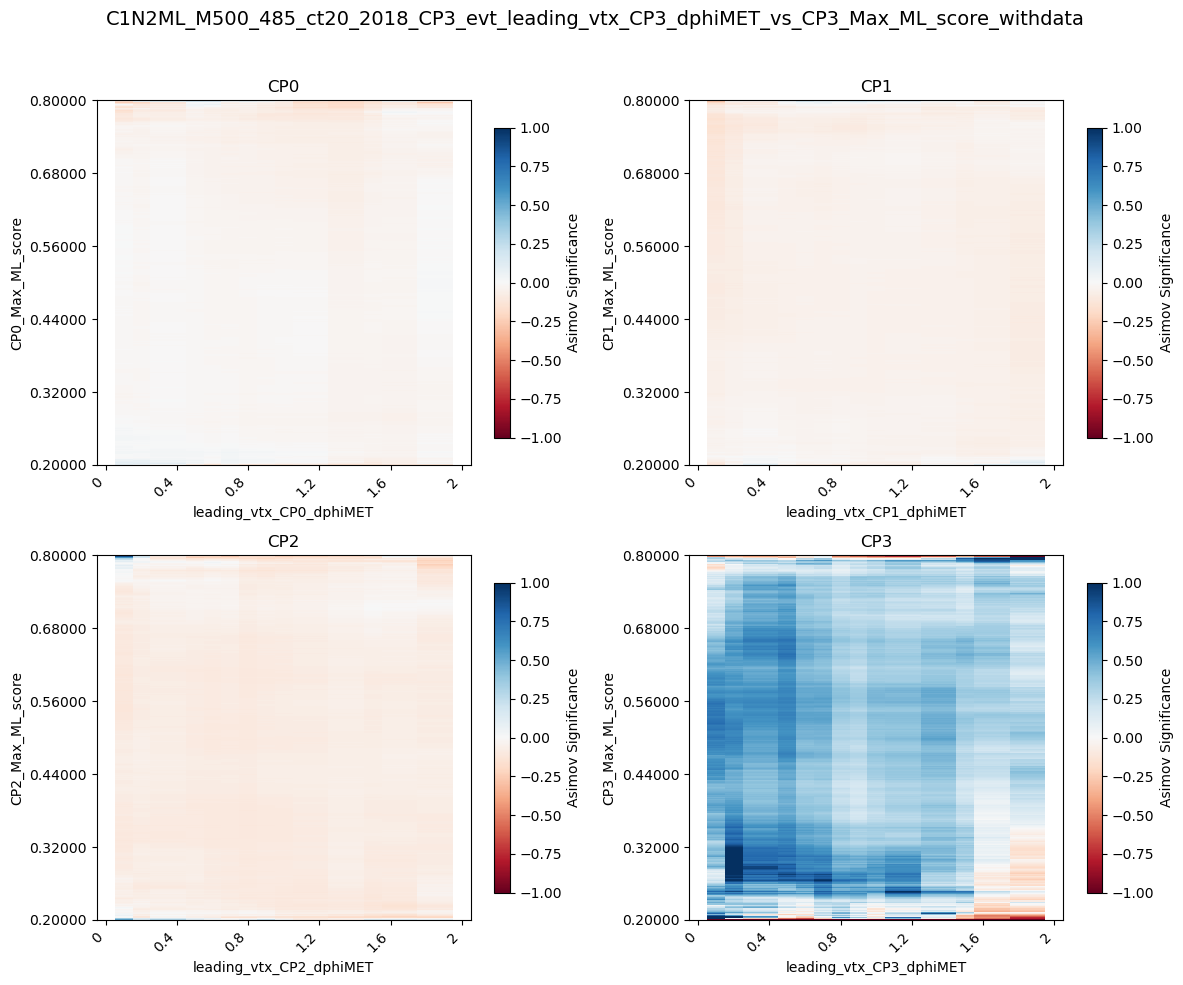

In [70]:
import matplotlib.ticker as mtick
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

plotlim_xlo = 0
plotlim_xup = 2
plotlim_ylo = 0.2
plotlim_yup = 0.8

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, PLANE in zip(axes, PLANEs[:4]):

    X_b = ((tables[PLANE][key]['bkg_NA'] * \
           tables[PLANE][key]['bkg_ND'] / \
           tables[PLANE][key]['bkg_NC']) - tables[PLANE][key]['bkg_NB']) / \
           tables[PLANE][key]['bkg_NB']


    X_b = X_b.loc[plotlim_xlo:plotlim_xup, plotlim_ylo:plotlim_yup]
    # X_b = X_b.fillna(0)

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    # absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="RdBu",
        vmin=-1,
        vmax=1,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel(f'leading_vtx_{PLANE}_dphiMET')
    ax.set_ylabel(f'{PLANE}_Max_ML_score')
    ax.set_title(PLANE)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
